### Cell 1: Imports & Setup

In [1]:
# GOAL:
#   Import the necessary libraries for data loading, visualization, PCA,
#   correlation checks, classification, and regression.

# WHY:
#   We need these libraries to handle a large dataset (pandas),
#   perform EDA (seaborn, matplotlib), do PCA (sklearn),
#   and build ML models (sklearn).

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


### Cell 2: Load & Merge the CSV Files

In [2]:
# GOAL:
#   Merge the 7 CSV parts (~42,000 samples) into a single DataFrame.

# WHY:
#   We want a unified dataset for consistent correlation checks, PCA, and modeling.

data_dir = "../dataset/UWB-LOS-NLOS-Data-Set/dataset/"  # Adjust if your notebook is in "models/" or a different location
csv_files = glob.glob(os.path.join(data_dir, "uwb_dataset_part*.csv"))

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

uwb_df = pd.concat(df_list, ignore_index=True)

print(f"Merged {len(csv_files)} files.")
print("Total rows:", len(uwb_df))
print("Columns:", uwb_df.columns.tolist())

# Quick preview
uwb_df.head()


Merged 7 files.
Total rows: 42000
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR0', 'CIR1', 'CIR2', 'CIR3', 'CIR4', 'CIR5', 'CIR6', 'CIR7', 'CIR8', 'CIR9', 'CIR10', 'CIR11', 'CIR12', 'CIR13', 'CIR14', 'CIR15', 'CIR16', 'CIR17', 'CIR18', 'CIR19', 'CIR20', 'CIR21', 'CIR22', 'CIR23', 'CIR24', 'CIR25', 'CIR26', 'CIR27', 'CIR28', 'CIR29', 'CIR30', 'CIR31', 'CIR32', 'CIR33', 'CIR34', 'CIR35', 'CIR36', 'CIR37', 'CIR38', 'CIR39', 'CIR40', 'CIR41', 'CIR42', 'CIR43', 'CIR44', 'CIR45', 'CIR46', 'CIR47', 'CIR48', 'CIR49', 'CIR50', 'CIR51', 'CIR52', 'CIR53', 'CIR54', 'CIR55', 'CIR56', 'CIR57', 'CIR58', 'CIR59', 'CIR60', 'CIR61', 'CIR62', 'CIR63', 'CIR64', 'CIR65', 'CIR66', 'CIR67', 'CIR68', 'CIR69', 'CIR70', 'CIR71', 'CIR72', 'CIR73', 'CIR74', 'CIR75', 'CIR76', 'CIR77', 'CIR78', 'CIR79', 'CIR80', 'CIR81', 'CIR82', 'CIR83', 'CIR84', 'CIR85', 'CIR86', 'CIR87', 'CIR88', 'CIR8

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


### Cell 3: Basic Inspection & Data Cleaning

In [3]:
# GOAL:
#   Inspect the dataset shape, descriptive stats, and handle any missing or duplicate data.

# WHY:
#   Ensuring data integrity is critical before correlation checks or PCA.

print("Data shape:", uwb_df.shape)

# Descriptive stats (limit columns shown if you have 1000+ columns)
with pd.option_context('display.max_columns', 20):
    print("\nDescriptive Stats (some columns may be truncated):\n", uwb_df.describe())

# Check missing values
missing_counts = uwb_df.isnull().sum()
missing_counts_nonzero = missing_counts[missing_counts > 0]
print("\nMissing values (non-zero):\n", missing_counts_nonzero)

# Example cleaning: drop rows with missing
if not missing_counts_nonzero.empty:
    uwb_df.dropna(inplace=True)
    print("Data shape after dropping rows with missing values:", uwb_df.shape)

# Optional: check duplicates
uwb_df.drop_duplicates(inplace=True)
print("Data shape after removing duplicates:", uwb_df.shape)


Data shape: (42000, 1031)

Descriptive Stats (some columns may be truncated):
                NLOS         RANGE        FP_IDX       FP_AMP1       FP_AMP2  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000      3.831519    745.654167   8127.521905  11425.259524   
std        0.500006      2.355976      4.505024   5393.330697   6235.434769   
min        0.000000      0.000000    707.000000      7.000000     63.000000   
25%        0.000000      1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000      3.480000    746.000000   7140.000000  12318.000000   
75%        1.000000      5.420000    748.000000  12273.000000  17310.000000   
max        1.000000     28.020000    848.000000  20572.000000  20624.000000   

            FP_AMP3   STDEV_NOISE       CIR_PWR     MAX_NOISE       RXPACC  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.00000   
mean    9738.106048     72.284571   9789.690214   131

### Cell 4: Correlation Check Among the 13 Core Features

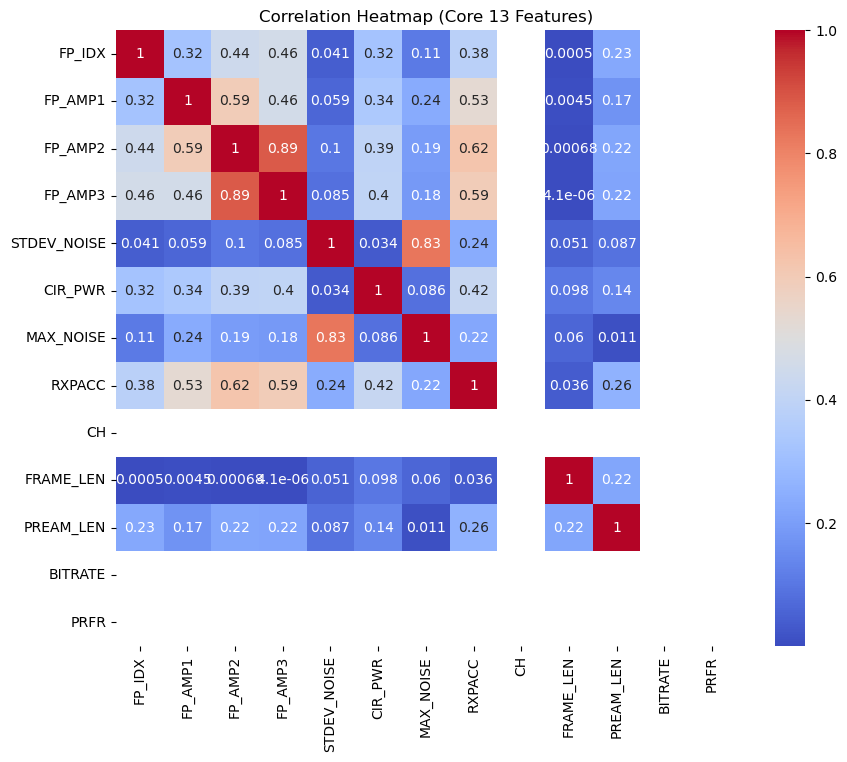

In [4]:
# GOAL:
#   Identify and optionally remove highly correlated core features
#   among these 13 columns (excluding NLOS and RANGE).

# WHY:
#   Redundant features can be dropped if correlation is above a threshold
#   (e.g., 0.80), preventing them from skewing modeling.

core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3", 
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"
]

# 1. Correlation matrix for these 13
corr_core = uwb_df[core_features].corr().abs()

# 2. Plot heatmap (may be large but let's do it)
plt.figure(figsize=(10,8))
sns.heatmap(corr_core, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Core 13 Features)")
plt.show()

# Reason:
#   This heatmap visually identifies pairs of features that are highly correlated.
#   If correlation > threshold (e.g., 0.80), we remove one to reduce redundancy.


- From here we set 80% benchmark to determine if features are highly correlated to each other.
- In this case, **FP_AMP2 & FP_AMP3** both **0.89** and **STDEV_NOISE & MAX_NOISE** both **0.83** are highly correlated.

### Cell 5: Checking Unique Values & Data Types for CH, BITRATE, PRFR

In [5]:
# GOAL:
#   Inspect the unique values, data types, and descriptive stats of CH, BITRATE, PRFR.

# WHY:
#   If these columns are constant or have almost no variation, they provide no predictive power
#   and won't correlate with anything. Also, we confirm they are numeric.

print("Unique CH values:", uwb_df["CH"].unique())
print("Unique BITRATE values:", uwb_df["BITRATE"].unique())
print("Unique PRFR values:", uwb_df["PRFR"].unique())

print("\nData Types:\n", uwb_df[["CH", "BITRATE", "PRFR"]].dtypes)
print("\nDescriptive Stats:\n", uwb_df[["CH", "BITRATE", "PRFR"]].describe())

# Reason:
#   If any column shows a single unique value or zero std, it's effectively constant.
#   Such columns can be dropped. If they're non-numeric, we must convert or drop them
#   before correlation or modeling.


Unique CH values: [2.]
Unique BITRATE values: [110.]
Unique PRFR values: [64.]

Data Types:
 CH         float64
BITRATE    float64
PRFR       float64
dtype: object

Descriptive Stats:
             CH  BITRATE     PRFR
count  42000.0  42000.0  42000.0
mean       2.0    110.0     64.0
std        0.0      0.0      0.0
min        2.0    110.0     64.0
25%        2.0    110.0     64.0
50%        2.0    110.0     64.0
75%        2.0    110.0     64.0
max        2.0    110.0     64.0


- If any column shows a single unique value or zero std, it's effectively constant.
- Such columns can be dropped. If they're non-numeric, we must convert or drop them before correlation or modeling.


### Cell 6: Correlation with RANGE for MAX_NOISE vs. STDEV_NOISE

In [6]:
# GOAL:
#   Check which of MAX_NOISE or STDEV_NOISE correlates more strongly (in absolute terms)
#   with the regression target RANGE.

# WHY:
#   If two features are correlated with each other, we only keep the one that better
#   explains RANGE for regression tasks.

corr_with_range = uwb_df[["MAX_NOISE", "STDEV_NOISE", "RANGE"]].corr()
print(corr_with_range["RANGE"])

# Reason:
#   The output shows correlation with RANGE:
#   - If |MAX_NOISE| > |STDEV_NOISE|, keep MAX_NOISE (drop STDEV_NOISE).
#   - If the opposite, keep STDEV_NOISE.
#   This approach picks the more predictive feature for range estimation.


MAX_NOISE     -0.260065
STDEV_NOISE    0.089544
RANGE          1.000000
Name: RANGE, dtype: float64


- We know that these 2 features are highly correlated so we can drop either one from Cell 4 visualization.
- But to know which to drop we can compare against with the target RANGE.
- In this case, MAX_NOISE more variance **0.260065(absolute)** compared to **STDEV_NOISE 0.089544**.


### Cell 7: Correlation with RANGE for FP_AMP2 vs. FP_AMP3

In [7]:
# GOAL:
#   Compare how strongly FP_AMP2 and FP_AMP3 each correlate with RANGE
#   to decide which one to keep if they're highly correlated.

# WHY:
#   If FP_AMP2 and FP_AMP3 are redundant, we keep the one that shows
#   stronger correlation (in absolute value) with the target RANGE.

corr_with_range_amp = uwb_df[["FP_AMP2", "FP_AMP3", "RANGE"]].corr()
print(corr_with_range_amp["RANGE"])

# Reason:
#   - If |FP_AMP2| > |FP_AMP3|, keep FP_AMP2 (drop FP_AMP3).
#   - If |FP_AMP3| > |FP_AMP2|, keep FP_AMP3.
#   This data-driven choice helps ensure the better explanatory feature remains.


FP_AMP2   -0.479689
FP_AMP3   -0.459521
RANGE      1.000000
Name: RANGE, dtype: float64


- We know that these 2 features are highly correlated so we can drop either one from Cell 4 visualization.
- But to know which to drop we can compare against with the target RANGE.
- In this case FP_AMP2 more variance **0.479689(absolute)** compared to **FP_AMP3 0.459521(absolute)**.


### Cell 8: Remove Redundant & Correlated Features

Dropped features: ['CH', 'BITRATE', 'PRFR', 'STDEV_NOISE', 'FP_AMP3']
Remaining core features: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN']
Number of remaining core features: 8


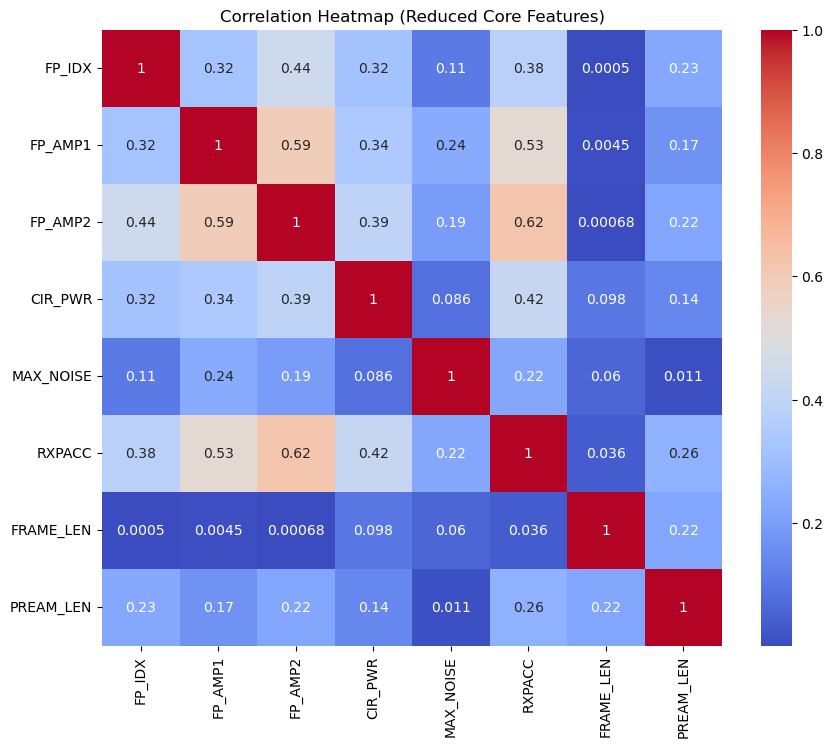

In [8]:
# GOAL:
#   Remove the identified 5 features from the core feature list, show how many remain,
#   then re-plot the correlation heatmap on the reduced set.

# WHY:
#   We want to ensure we've successfully removed redundant/constant features,
#   and verify that the remaining features have acceptable correlation levels.

# 1. Define the features to drop
features_to_drop = ["CH", "BITRATE", "PRFR", "STDEV_NOISE", "FP_AMP3"]

# 2. Remove them from your core feature list
final_core_features = [f for f in core_features if f not in features_to_drop]

print("Dropped features:", features_to_drop)
print("Remaining core features:", final_core_features)
print("Number of remaining core features:", len(final_core_features))

# 3. Re-check correlation on the remaining features
reduced_corr = uwb_df[final_core_features].corr().abs()

# 4. Plot the updated heatmap
plt.figure(figsize=(10,8))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Reduced Core Features)")
plt.show()


### Cell 9: Load and Normalize CIR Data

In [9]:
# GOAL:
#   Load the full set of CIR features (CIR0..CIR1015) plus RXPACC from multiple CSV files,
#   merge them into one DataFrame, and normalize the CIR columns by dividing by RXPACC.

# WHY:
#   The dataset's instructions recommend dividing CIR values by RXPACC (the number of
#   received preamble symbols) to obtain a per-preamble-pulse measure. This ensures
#   consistent CIR scaling across different samples that might have different RXPACC counts.

cir_columns = [f'CIR{i}' for i in range(1016)]

cir_df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(data_dir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        oneFileDF = pd.read_csv(filename, usecols=cir_columns + ['RXPACC'])
        if first > 0:
            first = 0
            cir_df = oneFileDF
        else:
            cir_df = pd.concat([cir_df, oneFileDF], ignore_index=True)

# Normalize the CIR columns by dividing each row's CIR data by its RXPACC value
cir_df[cir_columns] = cir_df[cir_columns].div(cir_df['RXPACC'], axis=0)

cir_df.head()

# Reason:
#   This step produces a single DataFrame 'cir_df' where each CIR column is normalized
#   to account for varying preamble counts, making the data ready for PCA or other analysis.


,RXPACC,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,611.0,0.211129,0.510638,0.541735,0.230769,0.261866,0.798691,0.319149,0.235679,0.194763,...,0.456628,0.749591,0.299509,0.258592,0.324059,0.142390,0.484452,0.826514,0.502455,0.000000
1,447.0,0.261745,0.364653,0.445190,0.304251,0.317673,0.407159,0.800895,0.275168,0.626398,...,0.322148,0.747204,0.648770,0.510067,0.418345,0.476510,0.451902,0.199105,0.230425,0.000000
2,723.0,0.598893,0.331950,0.322268,0.112033,0.197787,0.699862,0.164592,0.376210,0.343015,...,0.044260,0.515906,0.309820,0.240664,0.171508,0.455048,0.286307,0.132780,0.301521,0.000000
3,1024.0,0.455078,0.241211,0.397461,0.219727,0.272461,0.067383,0.383789,0.425781,0.282227,...,0.246094,0.168945,0.193359,0.156250,0.423828,0.387695,0.283203,0.151367,0.333984,0.250000
4,276.0,0.938406,0.865942,0.206522,0.068841,0.318841,0.793478,1.449275,0.547101,0.355072,...,0.557971,0.757246,0.876812,1.072464,0.315217,0.644928,1.137681,0.894928,1.057971,0.927536


- The dataset's instructions recommend dividing CIR values by RXPACC(the number of received preamble symbols) to obtain a per-preamble-pulse measure.
- This ensures consistent CIR scaling across different samples that might have different RXPACC counts.

### Cell 10: Use Normalize CIR Data to check linearity against Target RANGE

In [10]:
# GOAL:
#   Assess linear correlation of normalized CIR taps with RANGE,
#   and remove taps with weak correlation (|corr| ≤ 0.1).

# WHY:
#   CIR taps with low linear correlation to RANGE may introduce noise in regression or PCA,
#   so we drop them before modeling.

# 1. Get CIR tap columns (already normalized in cir_df)
cir_columns = [col for col in cir_df.columns if col.startswith("CIR")]

# 2. Add RANGE column from uwb_df to cir_df (for correlation calculation)
cir_df["RANGE"] = uwb_df["RANGE"]

# 3. Compute Pearson correlation with RANGE
correlations = cir_df[cir_columns].corrwith(cir_df["RANGE"])

# 4. Define threshold
threshold = 0.2

# 5. Determine which CIR taps to keep/drop
keep_cols = correlations[correlations.abs() > threshold].index.tolist()
drop_cols = correlations[correlations.abs() <= threshold].index.tolist()

# 7. Print summary
print(f"\nSummary of Linearity Check:")
print(f"  Linear CIR taps (|corr| > {threshold}): {len(keep_cols)} out of {len(cir_columns)}")
print(f"  Percentage with linear correlation: {100 * len(keep_cols) / len(cir_columns):.2f}%")

# 8. Print dropped columns
print("\n[INFO] CIR taps dropped due to weak correlation (|corr| ≤ 0.1):")
for col in drop_cols:
    print(f"  - {col}")
print(f"Number of CIR taps dropped: {len(drop_cols)}")

# 9. Create new DataFrame with only the kept CIR taps
filtered_cir_df = cir_df[keep_cols]

print(f"\n New DataFrame shape after dropping weak CIR taps: {filtered_cir_df.shape}")



Summary of Linearity Check:
  Linear CIR taps (|corr| > 0.2): 947 out of 1016
  Percentage with linear correlation: 93.21%

[INFO] CIR taps dropped due to weak correlation (|corr| ≤ 0.1):
  - CIR724
  - CIR726
  - CIR727
  - CIR728
  - CIR729
  - CIR730
  - CIR731
  - CIR732
  - CIR733
  - CIR734
  - CIR735
  - CIR736
  - CIR737
  - CIR738
  - CIR739
  - CIR740
  - CIR741
  - CIR742
  - CIR743
  - CIR744
  - CIR765
  - CIR766
  - CIR767
  - CIR768
  - CIR769
  - CIR770
  - CIR771
  - CIR772
  - CIR773
  - CIR774
  - CIR775
  - CIR776
  - CIR777
  - CIR778
  - CIR779
  - CIR780
  - CIR781
  - CIR782
  - CIR783
  - CIR784
  - CIR785
  - CIR786
  - CIR787
  - CIR788
  - CIR789
  - CIR790
  - CIR791
  - CIR792
  - CIR793
  - CIR798
  - CIR799
  - CIR800
  - CIR801
  - CIR802
  - CIR803
  - CIR804
  - CIR805
  - CIR806
  - CIR807
  - CIR808
  - CIR809
  - CIR810
  - CIR811
  - CIR812
  - CIR813
  - CIR814
  - CIR815
  - CIR816
  - CIR1015
Number of CIR taps dropped: 69

 New DataFrame shap

- 947 out of 1016 are consider linear correlation towards RANGE with 0.2 threshold set.
- 69 were dropped since its below the threshold which is deem as non-linearity.
- According to Cohen (1988), 0.2 is considered small effect, 0.5 medium and 0.8 large. Reference is from Cohen’s book, Statistical Power Analysis for the Behavioral Sciences (2nd ed). Hence, we choose 0.2 as the threshold for Pearson Correlation.

- Additional Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC3444174/

### Cell 11: PCA on CIR Features (Choosing 10 Components as initial)

In [11]:
# GOAL:
#   Apply PCA to reduce the 1,016 CIR columns down to 10 principal components,
#   and compute the explained variance for each component.

# WHY:
#   Reducing dimensionality speeds up further modeling while retaining the bulk
#   of the signal variance. Choosing 10 is a common compromise between
#   interpretability and information retention.

pca = PCA(n_components=10)
cir_pca = pca.fit_transform(filtered_cir_df)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print('Explained variance per component:', explained_variance_ratio)
print('Cumulative explained variance:', cumulative_explained_variance)

# Reason:
#   By fitting PCA with n_components=10, we see how much variance is captured
#   in those 10 PCs. If the cumulative variance is high (e.g., >80%),
#   it indicates a good dimension reduction choice.


Explained variance per component: [0.37399741 0.23623912 0.07786443 0.04890051 0.03711244 0.03105543
 0.0282938  0.02462044 0.02068704 0.01835367]
Cumulative explained variance: [0.37399741 0.61023653 0.68810096 0.73700146 0.7741139  0.80516934
 0.83346313 0.85808357 0.87877061 0.89712427]


- From here we can see the Cumlative explained variance >80% when Component=6 (0.80516934)

### Cell 12: Scree Plot (Cumulative Explained Variance)

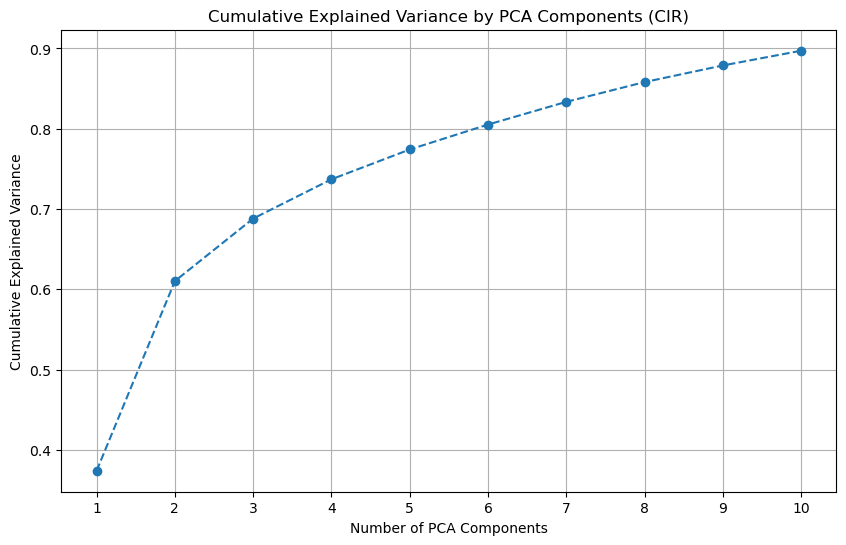

In [12]:
# GOAL:
#   Plot the cumulative explained variance of the 10 principal components
#   to visualize how quickly the variance is captured.

# WHY:
#   A scree plot helps confirm whether 10 components are sufficient
#   or if we should consider more. It's a visual way to see if
#   additional PCs beyond 8 add significant variance.

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker='o',
    linestyle='--'
)
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (CIR)')
plt.xticks(range(1, len(cumulative_explained_variance) + 1))
plt.grid(True)
plt.show()



### Cell 13: PCA on CIR Features (Finalizing with 6 PC Component)

In [13]:
pca = PCA(n_components=6)
cir_pca = pca.fit_transform(filtered_cir_df)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print('Explained variance per component:', explained_variance_ratio)
print('Cumulative explained variance:', cumulative_explained_variance)


Explained variance per component: [0.37399741 0.23623912 0.07786443 0.04890051 0.03711244 0.03105543]
Cumulative explained variance: [0.37399741 0.61023653 0.68810096 0.73700146 0.7741139  0.80516934]


- We selected 6 principal components because they collectively explain over 80% of the variance in the data.
- This follows a widely used rule of thumb in PCA, where 80–90% cumulative explained variance is generally considered sufficient to retain the majority of the information while reducing dimensionality. This threshold is supported in literature such as Jolliffe (2002), and is reflected in scikit-learn’s PCA implementation.

- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- https://link.springer.com/book/10.1007/b98835


### Cell 14: Scree Plot (Cumulative Explained Variance) Finalized

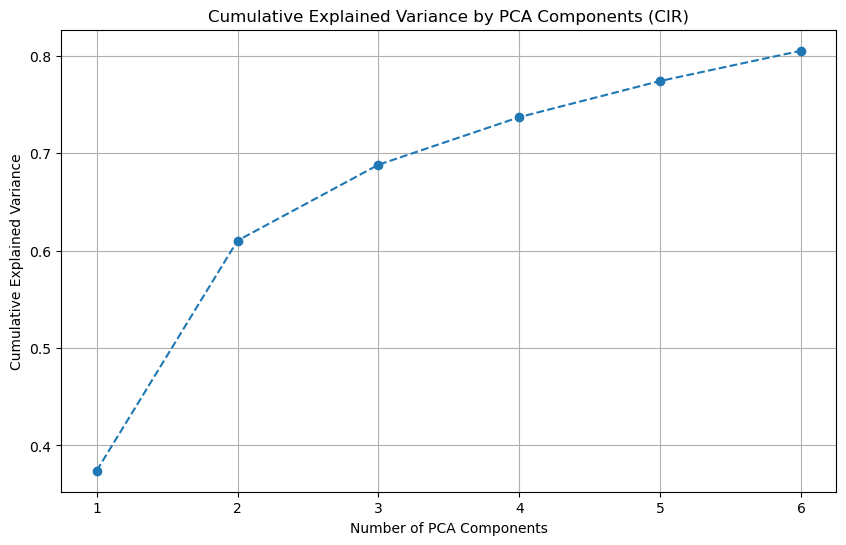

In [14]:
# GOAL:
#   Plot the cumulative explained variance of the 6 principal components
#   to visualize how quickly the variance is captured.

# WHY:
#   A scree plot helps confirm whether 6 components are sufficient
#   or if we should consider more. It's a visual way to see if
#   additional PCs beyond 6 add significant variance.

plt.figure(figsize=(10, 6))
plt.plot(range(1, 7), cumulative_explained_variance[:6], marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (CIR)')
plt.xticks(range(1, 7))
plt.grid(True)
plt.show()


### Cell 15: Visualisation (8-Reduce Features + 6-PC + 1-Target)

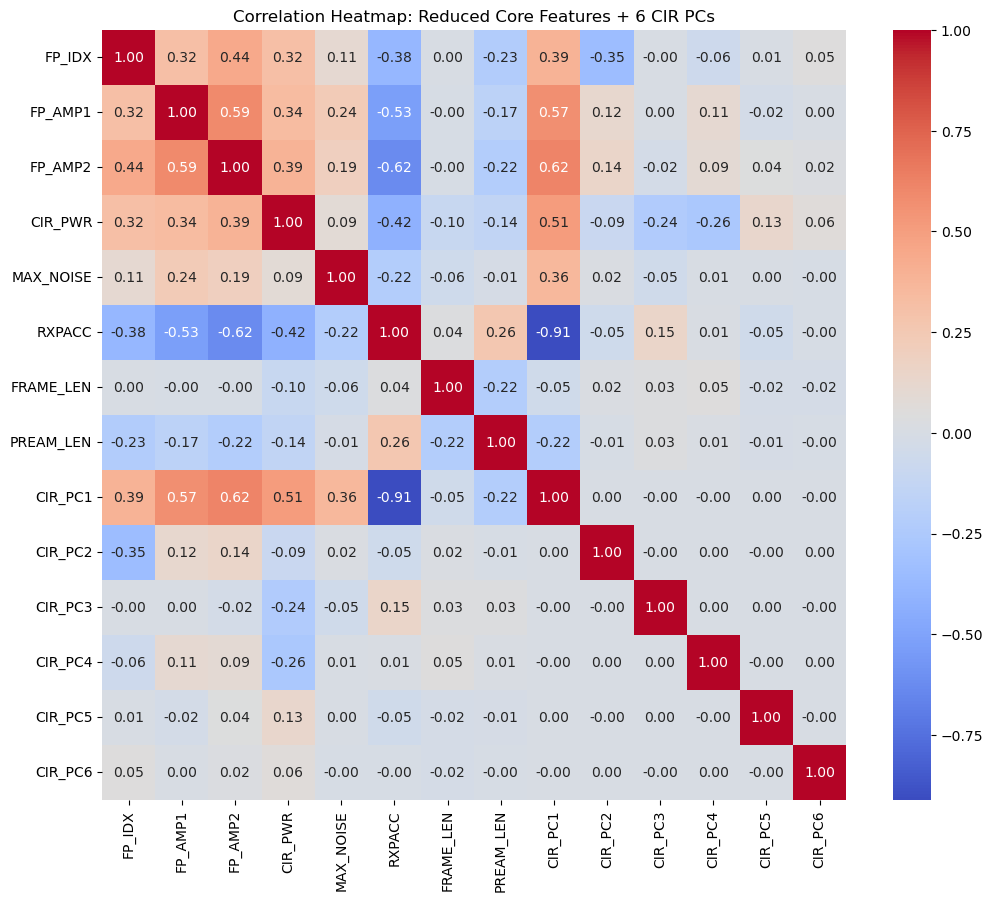

final_df shape: (42000, 15)
Columns in final_df: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'RANGE']


In [15]:
# ------------------------
# Final Cell: Combine Reduced Core Features + 6 PCA Components & Plot Correlation
# ------------------------

# 1. Define PCA column names
cir_pc_cols = [f"CIR_PC{i+1}" for i in range(6)]

# 2. Create a DataFrame from the PCA-transformed CIR data
cir_pca_df = pd.DataFrame(cir_pca, columns=cir_pc_cols)

# 3. Combine reduced core features + PCA components (and optionally labels)
#    - We reset_index(drop=True) to ensure the rows align properly during concat
final_df = pd.concat([
    uwb_df[final_core_features].reset_index(drop=True),  #  8 core features
    cir_pca_df.reset_index(drop=True),                   #  6 PCA columns
    uwb_df[["RANGE"]].reset_index(drop=True)     # keep RANGE label
], axis=1)

# 4. Plot a correlation heatmap of only the core features + PCA columns
features_for_heatmap = final_core_features + cir_pc_cols

plt.figure(figsize=(12, 10))
corr_final = final_df[features_for_heatmap].corr()
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Reduced Core Features + 6 CIR PCs")
plt.show()

# Print final_df shape to confirm everything merged as expected
print("final_df shape:", final_df.shape)
print("Columns in final_df:", final_df.columns.tolist())


- However, from this correlation heatmap, we can see that **CIR_PC1** and **RXPACC** are highly negative correlated with -0.91.

### Cell 16: Feature importance check using Random Forest Regressor

Feature Importances:
      Feature  Importance
5      RXPACC    0.449384
8     CIR_PC1    0.076638
3     CIR_PWR    0.076393
4   MAX_NOISE    0.048466
2     FP_AMP2    0.047158
7   PREAM_LEN    0.044027
1     FP_AMP1    0.041342
9     CIR_PC2    0.040187
11    CIR_PC4    0.040070
10    CIR_PC3    0.037591
12    CIR_PC5    0.034986
13    CIR_PC6    0.034381
0      FP_IDX    0.021873
6   FRAME_LEN    0.007503


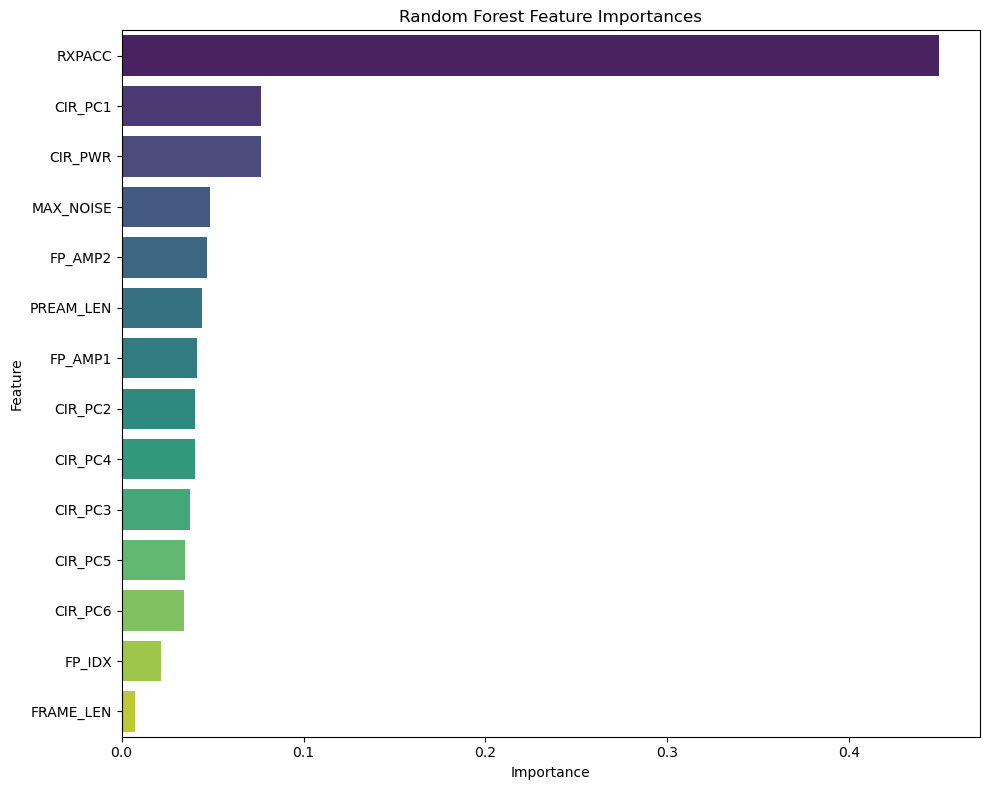

In [16]:
# ------------------------
# Feature Importance Using Random Forest Regressor
# ------------------------

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (reduced core features + 6 PCA components)
features = final_core_features + cir_pc_cols

# Define the target variable
y = final_df["RANGE"]
X = final_df[features]

# Train a Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract feature importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Print feature importance table
print("Feature Importances:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


- From this Bar plot, we can see that **RXPACC** has higher feature importance to the target Range compare to **CIR_PC1**.
- But we cannot simply based on this and dropped **CIR_PC1**, because this was after pca reduction so we cannot simply assume least importance then just dropped.
- Reason being, as you can see **CIR_PC1** ranked no. 2 so even though its correlated to **RXPACC**, it may still contribute meaningful or important data.
- We also notice that **FRAME_LEN has a 0.007506** contribution to the Target RANGE. 
- Hence, we need to do P-test for both to test out, as we cannot just assume to drop both **CIR_PC1 & FRAME_LEN**. 

### Cell 17: Train Test Split 0.3Test, 0.7Train (Note this for testing)

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# Step 1: Define Feature Sets and Target
# -----------------------------
# Assume these variables are defined from your previous cells:
# - final_core_features: a list with your 8 reduced core features
# - cir_pc_cols: a list with your 6 PCA component names (e.g., ["CIR_PC1", "CIR_PC2", ..., "CIR_PC6"])
# - final_df: final DataFrame that includes all features and the target 'RANGE'

# Full feature set: reduced core features + 6 PCA components
full_features = final_core_features + cir_pc_cols

# Target variable
y = final_df["RANGE"]

# -----------------------------
# Step 2: Train/Test Split with Full Features (for reference)
# -----------------------------
X_full = final_df[full_features]
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42)

rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_train_full, y_train)
score_full = rf_full.score(X_test_full, y_test)
print("R² score with full features:", score_full)

# -----------------------------
# Experiment 1: Remove PREAM_LEN only
# -----------------------------
features_remove_pream = [feat for feat in full_features if feat != "PREAM_LEN"]
X_remove_pream = final_df[features_remove_pream]
X_train_pream, X_test_pream, _, _ = train_test_split(X_remove_pream, y, test_size=0.3, random_state=42)

rf_remove_pream = RandomForestRegressor(n_estimators=100, random_state=42)
rf_remove_pream.fit(X_train_pream, y_train)
score_remove_pream = rf_remove_pream.score(X_test_pream, y_test)
print("R² score with PREAM_LEN removed:", score_remove_pream)

# -----------------------------
# Experiment 2: Remove CIR_PC1 only
# -----------------------------
features_remove_cir_pc1 = [feat for feat in full_features if feat != "CIR_PC1"]
X_remove_cir_pc1 = final_df[features_remove_cir_pc1]
X_train_cir, X_test_cir, _, _ = train_test_split(X_remove_cir_pc1, y, test_size=0.3, random_state=42)

rf_remove_cir_pc1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_remove_cir_pc1.fit(X_train_cir, y_train)
score_remove_cir_pc1 = rf_remove_cir_pc1.score(X_test_cir, y_test)
print("R² score with CIR_PC1 removed:", score_remove_cir_pc1)


R² score with full features: 0.5871014570852504
R² score with PREAM_LEN removed: 0.5868503737364148
R² score with CIR_PC1 removed: 0.5755476189906819


- Based on the results there is only slight significant difference, but still we cannot assume, **CAUSE WE NEED TO BE JUSTIFIED!** 
- Hence, as mention we need do the P-test to validate our result to see if it shows signifcant anot.

### Cell 18: Cross Validation with 5-fold from the above cell

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# -----------------------------
# Assume these variables are defined:
# - final_core_features: list with your 8 reduced core features
# - cir_pc_cols: list with your 6 PCA component names (e.g., ["CIR_PC1", "CIR_PC2", ..., "CIR_PC6"])
# - final_df: final DataFrame that includes all features and the target 'RANGE'
# - full_features: final_core_features + cir_pc_cols
# - y: final_df["RANGE"]

# -----------------------------
# 5-Fold CV using full features
# -----------------------------
cv_scores_full = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    final_df[full_features],
    y,
    cv=5,
    scoring='r2'
)
print("5-Fold CV R² with full features:", cv_scores_full)
print("Mean CV R² with full features:", np.mean(cv_scores_full))

# -----------------------------
# 5-Fold CV after removing PREAM_LEN
# -----------------------------
features_remove_pream = [feat for feat in full_features if feat != "PREAM_LEN"]
cv_scores_pream = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    final_df[features_remove_pream],
    y,
    cv=5,
    scoring='r2'
)
print("\n5-Fold CV R² with PREAM_LEN removed:", cv_scores_pream)
print("Mean CV R² with PREAM_LEN removed:", np.mean(cv_scores_pream))

# -----------------------------
# 5-Fold CV after removing CIR_PC1
# -----------------------------
features_remove_cir_pc1 = [feat for feat in full_features if feat != "CIR_PC1"]
cv_scores_cir_pc1 = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    final_df[features_remove_cir_pc1],
    y,
    cv=5,
    scoring='r2'
)
print("\n5-Fold CV R² with CIR_PC1 removed:", cv_scores_cir_pc1)
print("Mean CV R² with CIR_PC1 removed:", np.mean(cv_scores_cir_pc1))


5-Fold CV R² with full features: [0.59111661 0.59807335 0.59667305 0.57232739 0.59189375]
Mean CV R² with full features: 0.5900168317628

5-Fold CV R² with PREAM_LEN removed: [0.59099794 0.598106   0.59642334 0.57315175 0.59253443]
Mean CV R² with PREAM_LEN removed: 0.5902426917781037

5-Fold CV R² with CIR_PC1 removed: [0.57989465 0.58904591 0.57879218 0.5626569  0.58227596]
Mean CV R² with CIR_PC1 removed: 0.5785331205903913


- We use the result obtain in Cell 19 then put into Cell 20.

### Cell 19: T and P-test

In [19]:
from scipy.stats import ttest_rel
import numpy as np

# Cross-validation R² scores from your results
cv_scores_full = np.array([0.59251502, 0.59864387, 0.59683112, 0.57263316, 0.59193769])
cv_scores_pream = np.array([0.59077188, 0.59821204, 0.5967529 , 0.57252069, 0.59313619])
cv_scores_cirpc1 = np.array([0.58042914, 0.5888737 , 0.57946321, 0.56328059, 0.58293278])

# 1) Compare Full vs. Removing PREAM_LEN
t_stat_pream, p_value_pream = ttest_rel(cv_scores_full, cv_scores_pream)
print("Full vs. PREAM_LEN removed")
print("  T-statistic:", t_stat_pream)
print("  P-value:", p_value_pream)

# 2) Compare Full vs. Removing CIR_PC1
t_stat_cirpc1, p_value_cirpc1 = ttest_rel(cv_scores_full, cv_scores_cirpc1)
print("\nFull vs. CIR_PC1 removed")
print("  T-statistic:", t_stat_cirpc1)
print("  P-value:", p_value_cirpc1)


Full vs. PREAM_LEN removed
  T-statistic: 0.4972420023989649
  P-value: 0.6451089984812954

Full vs. CIR_PC1 removed
  T-statistic: 7.387433290503282
  P-value: 0.0017902057346165859


- PREAM_LEN: The paired t-test gives a p-value of 0.645, which is much higher than 0.05. This means there's no significant difference in model performance when PREAM_LEN is removed. You can simplify your model by dropping this feature.

- CIR_PC1: The paired t-test gives a p-value of 0.00179, which is well below 0.05. This indicates that removing CIR_PC1 leads to a significant drop in performance, so it should be retained.

- https://www.scientificamerican.com/article/the-significant-problem-of-p-values/

### Cell 20: Finalized Pre-Processing Data

In [20]:
# ------------------------
# Final Cell: Combine Reduced Core Features + 6 PCA Components, Drop PREAM_LEN, Check for NaNs, and Save CSV
# ------------------------

# 1. Define PCA column names
cir_pc_cols = [f"CIR_PC{i+1}" for i in range(6)]

# 2. Create a DataFrame from the PCA-transformed CIR data
cir_pca_df = pd.DataFrame(cir_pca, columns=cir_pc_cols)

# 3. Combine reduced core features + PCA components (and the RANGE label)
#    We use reset_index(drop=True) to ensure proper alignment when concatenating
final_df = pd.concat([
    uwb_df[final_core_features].reset_index(drop=True),  # 8 core features
    cir_pca_df.reset_index(drop=True),                   # 6 PCA columns
    uwb_df[["RANGE"]].reset_index(drop=True)             # RANGE label
], axis=1)

# 4. Print current final_df shape and columns before dropping PREAM_LEN
print("Before dropping PREAM_LEN:")
print("final_df shape:", final_df.shape)
print("Columns in final_df:", final_df.columns.tolist())

# 5. Drop PREAM_LEN if it exists
if 'PREAM_LEN' in final_df.columns:
    final_df = final_df.drop(columns=['PREAM_LEN'])
    print("\nPREAM_LEN column dropped.")
else:
    print("\nPREAM_LEN column not found, nothing dropped.")

# 6. Print final_df shape, columns, and a preview of the data after dropping PREAM_LEN
print("\nAfter dropping PREAM_LEN:")
print("final_df shape:", final_df.shape)
print("Columns in final_df:", final_df.columns.tolist())
print("\nPreview of the data:")
print(final_df.head())

# 7. Check for missing values (NaN) in the final DataFrame
print("\nMissing values per column:")
print(final_df.isna().sum())

total_missing = final_df.isna().sum().sum()
print(f"\nTotal missing values in final_df: {total_missing}")

# 8. Save the final DataFrame as CSV to the specified path
csv_path = '../dataset/prepared/final_preprocessed_6PCs.csv'
final_df.to_csv(csv_path, index=False)
print(f"\nCSV file saved to: {csv_path}")


Before dropping PREAM_LEN:
final_df shape: (42000, 15)
Columns in final_df: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'RANGE']

PREAM_LEN column dropped.

After dropping PREAM_LEN:
final_df shape: (42000, 14)
Columns in final_df: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'RANGE']

Preview of the data:
   FP_IDX  FP_AMP1  FP_AMP2  CIR_PWR  MAX_NOISE  RXPACC  FRAME_LEN    CIR_PC1  \
0   745.0  18712.0  10250.0  11855.0      967.0   611.0       39.0  -9.034594   
1   749.0  11239.0   6313.0  18968.0     1133.0   447.0       27.0  25.389144   
2   746.0   4355.0   5240.0  14699.0      894.0   723.0       27.0 -19.931322   
3   750.0   8502.0   8416.0   8748.0     1127.0  1024.0       39.0 -38.491470   
4   746.0  17845.0  18095.0  11380.0     1744.0   276.0       27.0  58.